<a href="https://colab.research.google.com/github/Sanathcharan/Data-Science-ExcelR/blob/main/bagging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('sales.csv')
df

,Unnamed: 0,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,high
0,1,138,73,11,276,120,Bad,42,17,Yes,Yes,yes
1,2,111,48,16,260,83,Good,65,10,Yes,Yes,yes
2,3,113,35,10,269,80,Medium,59,12,Yes,Yes,yes
3,4,117,100,4,466,97,Medium,55,14,Yes,Yes,no
4,5,141,64,3,340,128,Bad,38,13,Yes,No,no
...,...,...,...,...,...,...,...,...,...,...,...,...
395,396,138,108,17,203,128,Good,33,14,Yes,Yes,yes
396,397,139,23,3,37,120,Medium,55,11,No,Yes,no
397,398,162,26,12,368,159,Medium,40,18,Yes,Yes,no
398,399,100,79,7,284,95,Bad,50,12,Yes,Yes,no


In [ ]:
df.drop(columns='Unnamed: 0',inplace=True)

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CompPrice    400 non-null    int64 
 1   Income       400 non-null    int64 
 2   Advertising  400 non-null    int64 
 3   Population   400 non-null    int64 
 4   Price        400 non-null    int64 
 5   ShelveLoc    400 non-null    object
 6   Age          400 non-null    int64 
 7   Education    400 non-null    int64 
 8   Urban        400 non-null    object
 9   US           400 non-null    object
 10  high         400 non-null    object
dtypes: int64(7), object(4)
memory usage: 34.5+ KB


In [ ]:
df.size

4400

In [ ]:
df.shape

(400, 11)

In [ ]:
df.isnull().sum()

,0
CompPrice,0
Income,0
Advertising,0
Population,0
Price,0
ShelveLoc,0
Age,0
Education,0
Urban,0
US,0


In [ ]:
df.duplicated().sum()

np.int64(0)

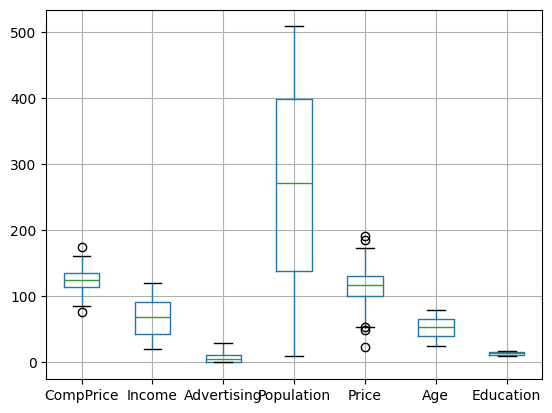

In [ ]:
df.boxplot()
plt.show()

In [ ]:
for i in df.select_dtypes(include=['int','float']).columns:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    IQR=q3-q1
    lower_bound=q1-1.5*IQR
    upper_bound=q3+1.5*IQR
    df[i]=df[i].clip(lower_bound,upper_bound)

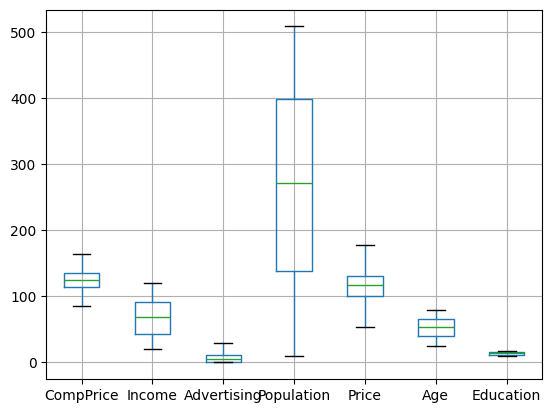

In [ ]:
df.boxplot()
plt.show()

In [ ]:
df

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,high
0,138,73,11,276,120.0,Bad,42,17,Yes,Yes,yes
1,111,48,16,260,83.0,Good,65,10,Yes,Yes,yes
2,113,35,10,269,80.0,Medium,59,12,Yes,Yes,yes
3,117,100,4,466,97.0,Medium,55,14,Yes,Yes,no
4,141,64,3,340,128.0,Bad,38,13,Yes,No,no
...,...,...,...,...,...,...,...,...,...,...,...
395,138,108,17,203,128.0,Good,33,14,Yes,Yes,yes
396,139,23,3,37,120.0,Medium,55,11,No,Yes,no
397,162,26,12,368,159.0,Medium,40,18,Yes,Yes,no
398,100,79,7,284,95.0,Bad,50,12,Yes,Yes,no


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()
df[['ShelveLoc']]=oe.fit_transform(df[['ShelveLoc']])
df

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,high
0,138,73,11,276,120.0,0.0,42,17,Yes,Yes,yes
1,111,48,16,260,83.0,1.0,65,10,Yes,Yes,yes
2,113,35,10,269,80.0,2.0,59,12,Yes,Yes,yes
3,117,100,4,466,97.0,2.0,55,14,Yes,Yes,no
4,141,64,3,340,128.0,0.0,38,13,Yes,No,no
...,...,...,...,...,...,...,...,...,...,...,...
395,138,108,17,203,128.0,1.0,33,14,Yes,Yes,yes
396,139,23,3,37,120.0,2.0,55,11,No,Yes,no
397,162,26,12,368,159.0,2.0,40,18,Yes,Yes,no
398,100,79,7,284,95.0,0.0,50,12,Yes,Yes,no


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['high']=le.fit_transform(df['high'])
df

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,high
0,138,73,11,276,120.0,0.0,42,17,Yes,Yes,1
1,111,48,16,260,83.0,1.0,65,10,Yes,Yes,1
2,113,35,10,269,80.0,2.0,59,12,Yes,Yes,1
3,117,100,4,466,97.0,2.0,55,14,Yes,Yes,0
4,141,64,3,340,128.0,0.0,38,13,Yes,No,0
...,...,...,...,...,...,...,...,...,...,...,...
395,138,108,17,203,128.0,1.0,33,14,Yes,Yes,1
396,139,23,3,37,120.0,2.0,55,11,No,Yes,0
397,162,26,12,368,159.0,2.0,40,18,Yes,Yes,0
398,100,79,7,284,95.0,0.0,50,12,Yes,Yes,0


In [ ]:
df=pd.get_dummies(df,dtype='int')
df

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,high,Urban_No,Urban_Yes,US_No,US_Yes
0,138,73,11,276,120.0,0.0,42,17,1,0,1,0,1
1,111,48,16,260,83.0,1.0,65,10,1,0,1,0,1
2,113,35,10,269,80.0,2.0,59,12,1,0,1,0,1
3,117,100,4,466,97.0,2.0,55,14,0,0,1,0,1
4,141,64,3,340,128.0,0.0,38,13,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,138,108,17,203,128.0,1.0,33,14,1,0,1,0,1
396,139,23,3,37,120.0,2.0,55,11,0,1,0,0,1
397,162,26,12,368,159.0,2.0,40,18,0,0,1,0,1
398,100,79,7,284,95.0,0.0,50,12,0,0,1,0,1


In [ ]:
x=df.drop(columns='high')
y=df['high']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=50,stratify=df.high)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(criterion='entropy',max_depth=4,splitter='random')
dt.fit(x_train,y_train)
pred_train=dt.predict(x_train)
pred_test=dt.predict(x_test)
from sklearn.metrics import accuracy_score
print("Train accuracy is ",accuracy_score(y_train,pred_train))
print("Test accuracy is ",accuracy_score(y_test,pred_test))

Train accuracy is  0.746875
Test accuracy is  0.725


In [ ]:
# bagging classifier
from sklearn.ensemble import BaggingClassifier
bagging_model=BaggingClassifier(estimator=DecisionTreeClassifier(criterion='gini'),n_estimators=100,random_state=42,max_samples=0.6,max_features=0.7,bootstrap_features=True)
bagging_model.fit(x_train,y_train)
y_pred_train_bagging=bagging_model.predict(x_train)
y_pred_test_bagging=bagging_model.predict(x_test)
training_accuracy_bagging=accuracy_score(y_train,y_pred_train_bagging)
testing_accuracy_bagging=accuracy_score(y_test,y_pred_test_bagging)
print("Training accuracy is ",np.round(training_accuracy_bagging,2))
print("Testing accuracy is ",np.round(testing_accuracy_bagging,2))

Training accuracy is  1.0
Testing accuracy is  0.84


In [ ]:
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression()
bagging_model=BaggingClassifier(estimator=lg,n_estimators=100,random_state=42,max_samples=0.6,max_features=0.7,bootstrap_features=True)
bagging_model.fit(x_train,y_train)
y_pred_train_bagging=bagging_model.predict(x_train)
y_pred_test_bagging=bagging_model.predict(x_test)
training_accuracy_bagging=accuracy_score(y_train,y_pred_train_bagging)
testing_accuracy_bagging=accuracy_score(y_test,y_pred_test_bagging)
print("Training accuracy is ",np.round(training_accuracy_bagging,2))
print("Testing accuracy is ",np.round(testing_accuracy_bagging,2))

Training accuracy is  0.78
Testing accuracy is  0.8


In [ ]:
from sklearn.svm import SVC
svc=SVC()
bagging_model=BaggingClassifier(estimator=svc,n_estimators=100,random_state=42,max_samples=0.6,max_features=0.7,bootstrap_features=True)
bagging_model.fit(x_train,y_train)
y_pred_train_bagging=bagging_model.predict(x_train)
y_pred_test_bagging=bagging_model.predict(x_test)
training_accuracy_bagging=accuracy_score(y_train,y_pred_train_bagging)
testing_accuracy_bagging=accuracy_score(y_test,y_pred_test_bagging)
print("Training accuracy is ",np.round(training_accuracy_bagging,2))
print("Testing accuracy is ",np.round(testing_accuracy_bagging,2))

Training accuracy is  0.59
Testing accuracy is  0.59


In [ ]:
# bagging classifier
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(n_estimators=100,random_state=42,max_samples=0.6,max_features=0.7,max_depth=10)
rf_model.fit(x_train,y_train)
y_pred_train_rf=rf_model.predict(x_train)
y_pred_test_rf=rf_model.predict(x_test)
training_accuracy_rf=accuracy_score(y_train,y_pred_train_rf)
testing_accuracy_rf=accuracy_score(y_test,y_pred_test_rf)
print("Training accuracy is ",np.round(training_accuracy_rf,2))
print("Testing accuracy is ",np.round(testing_accuracy_rf,2))

Training accuracy is  1.0
Testing accuracy is  0.8


In [ ]:
from sklearn.model_selection import GridSearchCV
# define the parameter grid
param_grid = {
    'n_estimators': [50, 100,200],
    'max_samples':[0.6,0.7,0.8],
    'max_features':[0.6,0.7,0.8]
}
# create a randomforestclassifier
rf_model = RandomForestClassifier(random_state=42,max_depth=10)
# create a gridsearchcv object
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5,scoring='accuracy')
# fit the gridsearchcv object to the data
grid_search.fit(x_train, y_train)
# print the best parameters and score
print("Best hyperparameters: ",grid_search.best_params_)
print("Best parameters: ", grid_search.best_score_)

Best hyperparameters:  {'max_features': 0.6, 'max_samples': 0.8, 'n_estimators': 50}
Best parameters:  0.815625


In [ ]:
# evaluate the best model on the test set
best_rf_model = grid_search.best_estimator_
y_pred_test_best=best_rf_model.predict(x_test)
y_pred_train_best=best_rf_model.predict(x_train)
test_accuracy_best =accuracy_score(y_test,y_pred_test_best)
# train_accuracy_best=accuracy_score(y_train,y_pred_train_best)
# print("train accuracy of best model: ",np.round(train_accuracy_best,2))
print("Test accuracy of best model: ", np.round(test_accuracy_best,2))

Test accuracy of best model:  0.76
